Always Accept Total Reward: -5272
Priority + ICU Total Reward: -387
Conservative + ICU Total Reward: -95
Random Total Reward: -1733


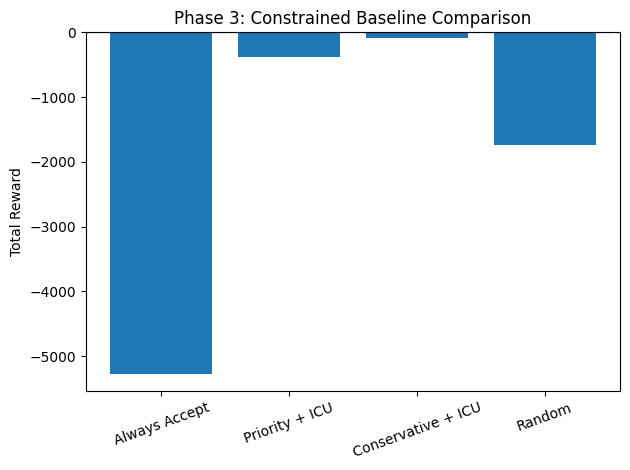

In [2]:
import sys
import os
import random
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Setup Project Path
# -------------------------------
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

from utils.hospital_env import HospitalEnv

# -------------------------------
# Reproducibility
# -------------------------------
random.seed(42)

# -------------------------------
# Load Data
# -------------------------------
data = pd.read_csv("../data/synthetic_hospital_data.csv")


# -------------------------------
# Baseline Runner Function
# -------------------------------
def run_baseline(policy_function):
    env = HospitalEnv(data)
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = policy_function(state)
        state, reward, done = env.step(action)
        total_reward += reward

    return total_reward


# -------------------------------
# Baseline Policies
# -------------------------------

# A: Always Accept
def always_accept_policy(state):
    return 1


# B: Priority + ICU Aware (Improved)
def priority_policy(state):
    _, _, priority, _, icu_ratio = state

    if priority == 2:  # Critical
        return 1

    if priority == 1 and icu_ratio < 0.9:
        return 1

    return 0


# C: Conservative + ICU Aware (Improved)
def conservative_policy(state):
    _, _, priority, no_show_prob, icu_ratio = state

    # Always accept critical
    if priority == 2:
        return 1

    if no_show_prob < 0.2 and icu_ratio < 0.85:
        return 1

    return 0


# D: Random
def random_policy(state):
    return random.randint(0, 1)


# -------------------------------
# Run All Baselines
# -------------------------------
results = {
    "Always Accept": run_baseline(always_accept_policy),
    "Priority + ICU": run_baseline(priority_policy),
    "Conservative + ICU": run_baseline(conservative_policy),
    "Random": run_baseline(random_policy)
}

# -------------------------------
# Print Results
# -------------------------------
for name, reward in results.items():
    print(f"{name} Total Reward: {reward}")

# -------------------------------
# Plot Comparison
# -------------------------------
plt.figure()
plt.bar(results.keys(), results.values())
plt.ylabel("Total Reward")
plt.title("Phase 3: Constrained Baseline Comparison")
plt.axhline(0, color="black", linestyle="--")
plt.axhline(0, color="black", linestyle="--")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
